<div align="center" style="font-family: Arial; line-height:1.8;">
<h1 style="text-align:center;"><b>MSIN0097 Predictive Analytics Individual Assignment</b></h1>
<h2 style="text-align:center;"><b>Bank Customer Attrition Prediction</b></h3>

<h3 style="text-align:center;"><b>Candidate Number: VWNP8</b></h3>

In [1]:
# ================== Notebook Setup ==================
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# ================== Data Library ==================
from __future__ import annotations

import json
import seaborn as sns
import random
import sys
from datetime import datetime
from pathlib import Path

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# ================== Global Configuration ==================
SEED = 42

In [3]:
# ================== Setup Directory Structure ==================
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent

# Create subdirectories for organized asset management
RAW_DATA_PATH = PROJECT_ROOT / 'data' / 'bank_churn_dataset.csv'
OUT_DIR = PROJECT_ROOT / 'artifacts'
AUDIT_DIR = OUT_DIR / 'audit'
MODELS_DIR = OUT_DIR / 'models'
PLOTS_DIR = OUT_DIR / 'plots'
REPORTS_DIR = OUT_DIR / 'reports'
TABLES_DIR = OUT_DIR / 'tables'

# Initialize directories if they do not exist
# Ensure the folder structure is ready before saving any files
for folder in [OUT_DIR, AUDIT_DIR, MODELS_DIR, PLOTS_DIR, REPORTS_DIR,TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Table of Contents
1. Section 1: Obtain a Dataset and Frame the Predictive Problem
2. Section 2: Explore the Data to Gain Insights
3. Section 3: Prepare Data (Industrial Pipeline Setup)
4. Section 4: Select and Train Models (`src/train.py`)
5. Section 5: Tune and Evaluate (`src/tune.py`, `src/evaluate.py`)
6. Section 6: Final Solution and Model Card


# Section 1: Obtain a Dataset and Frame the Predictive Problem

## Download the Data

In [4]:
# Upload the original data set
raw_data = pd.read_csv(RAW_DATA_PATH, encoding="utf-8")
print('Raw shape:', raw_data.shape)
print('Columns:', len(raw_data.columns))

Raw shape: (10127, 23)
Columns: 23


## A Brief Overview of The Data Structure

In [5]:
raw_data["CLIENTNUM"].duplicated().sum()

np.int64(0)

In [6]:
cols_to_drop = [
    "CLIENTNUM",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
]

# Create a new DataFrame with only selected columns
raw_data_new = raw_data.drop(columns = cols_to_drop)
raw_data_new.head() # Show first few rows

,Attrition_Flag,Customer_Age,Gender,Dependent_Count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_Book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


<div align="center">

| Variable                  | Explanation                                                                                               |
|-------------------------  |---------------------------------------------------------------------------------------------------------- |
|Attrition_Flag             |Target Variable - Customer Activity Status Indicating Whether the Client Has Attrited or Remains Active    |
|Customer_Age               |Age of the Customer in Years                                                                               |
|Gender                     |Customer Gender (F = Female, M = Male)                                                                     |
|Denpendent_Count           |Number of Financial Dependents Associated with the Customer                                                |
|Education_Level            |Highest Educational Qualification of the Customer                                                          |
|Marital_Status             |Marital Status Category (Married, Single, Divorced, Unknown)                                               |
|Income_Category            |Annual Income Bracket of the Customer                                                                      |
|Card_Category              |Type of Credit Card Held (Blue, Silver, Gold, Platinum)                                                    |          
|Months_on_Book             |Length of the Customer Relationship with the Bank                                                          |
|Total_Relationship_Count   |Total Number of Financial Products Held by the Customer                                                    |
|Months_Inactive_12_mon     |Number of Months with No Recorded Activity in the Past 12 Months                                           |
|Contacts_Count_12_mon      |Number of Contacts Between the Customer and the Bank in the Past 12 Months                                 |
|Credit_Limit               |Credit Limit on the Credit Card                                                                            |
|Total_Revolving_Bal        |Total Revolving Balance on the Credit Card                                                                 |
|Avg_Open_To_Buy            |Average Available Credit Line over the Past 12 Months                                                      |
|Total_Trans_Amt            |Total Transaction Amount Recorded in the Past 12 Months                                                    |
|Total_Trans_Ct             |Total Number of Transactions in the Past 12 Months                                                         |
|Total_Amt_Chng_Q4_Q1       |Change in Transaction Amount (Q4 over Q1)                                  |
|Total_Ct_Chng_Q4_Q1        |Change in Transaction Count (Q4 over Q1)                                   |
|Avg_Utilization_Ratio      |Average Card Utilization Ratio                                             |

</div>

In [7]:
raw_data_new.info() # Check data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_Count           10127 non-null  int64  
 4   Education_Level           10127 non-null  object 
 5   Marital_Status            10127 non-null  object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_Book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [8]:
for column in raw_data_new.select_dtypes(include="object").columns:
    missing_value = raw_data_new[column].value_counts().get("Unknown", 0)
    print(f"{column}:{missing_value}")

Attrition_Flag:0
Gender:0
Education_Level:1519
Marital_Status:749
Income_Category:1112
Card_Category:0


Text(0, 0.15199506270366347, '0.1500')

Text(1, 0.11180547052434087, '0.1098')

Text(2, 0.07596069912116125, '0.0740')

Text(0.5, 1.0, "Implicit Missingness by Column (Category: 'Unknown')")

Text(0, 0.5, 'Proportion of Records')

Text(0.5, 0, 'Categorical Features')

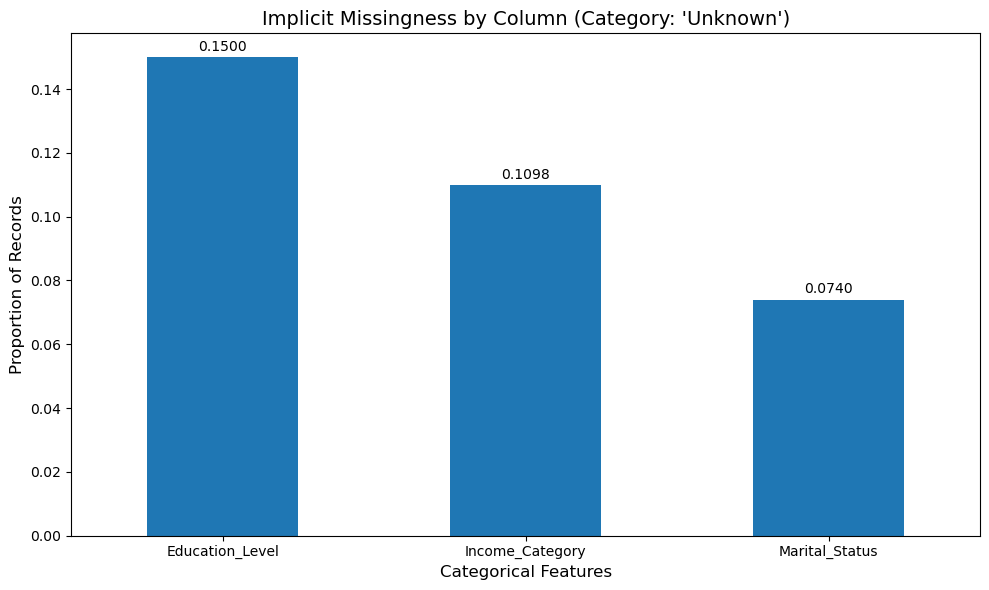

In [9]:
unknown_ratio = (
    (raw_data_new.select_dtypes(include="object") == "Unknown")
    .mean()
    .sort_values(ascending=False)
)
unknown_ratio = unknown_ratio[unknown_ratio > 0]

fig_unknown_ratio = unknown_ratio.plot(
    kind="bar",
    figsize=(10, 6),
    rot=0
)

for i, v in enumerate(unknown_ratio.values):
    fig_unknown_ratio.text(
        i,
        v + 0.002,
        f"{v:.4f}",
        ha="center",
        fontsize=10
    )

plt.title("Implicit Missingness by Column (Category: 'Unknown')", fontsize=14)
plt.ylabel("Proportion of Records", fontsize=12)
plt.xlabel("Categorical Features", fontsize=12)

plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'Customer_Age'}>,
        <Axes: title={'center': 'Months_on_Book'}>,
        <Axes: title={'center': 'Credit_Limit'}>],
       [<Axes: title={'center': 'Total_Revolving_Bal'}>,
        <Axes: title={'center': 'Avg_Open_To_Buy'}>,
        <Axes: title={'center': 'Total_Amt_Chng_Q4_Q1'}>],
       [<Axes: title={'center': 'Total_Trans_Amt'}>,
        <Axes: title={'center': 'Total_Trans_Ct'}>,
        <Axes: title={'center': 'Total_Ct_Chng_Q4_Q1'}>],
       [<Axes: title={'center': 'Avg_Utilization_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

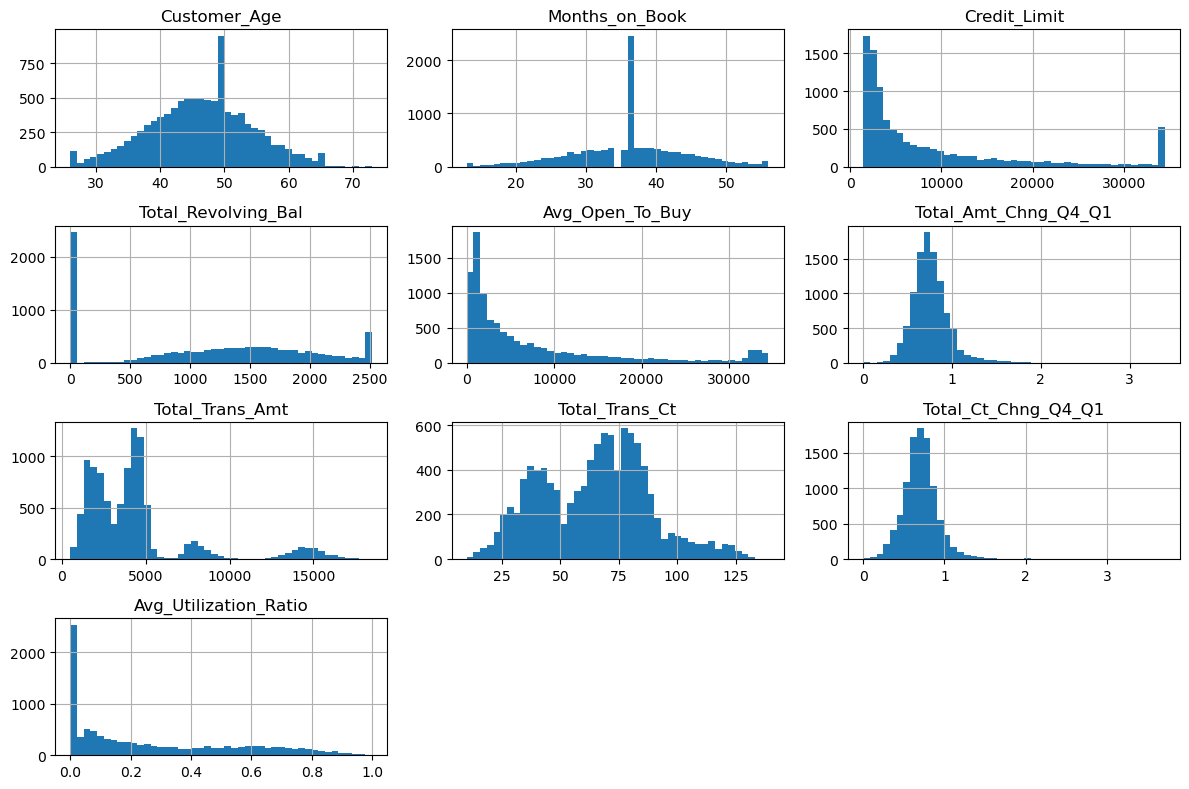

In [10]:
continuous_cols = [
    "Customer_Age",
    "Months_on_Book",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio"
]

raw_data_new[continuous_cols].hist(
    bins=45, 
    figsize=(12,8),
)
plt.tight_layout()
plt.show()

In [11]:
numerical_columns = raw_data_new.select_dtypes(include=np.number).columns

def iqr_outlier_ratio(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((series < lower_bound) | (series > upper_bound)).sum()
    return outliers / len(series)

outlier_summary = pd.DataFrame({
    "Outlier_Ratio": [iqr_outlier_ratio(raw_data_new[col]) for col in numerical_columns]
}, index=numerical_columns)

outlier_summary = outlier_summary.sort_values(by="Outlier_Ratio", ascending=False)
outlier_summary

,Outlier_Ratio
Credit_Limit,0.097166
Avg_Open_To_Buy,0.095092
Total_Trans_Amt,0.088476
Contacts_Count_12_mon,0.062111
Total_Amt_Chng_Q4_Q1,0.039103
Total_Ct_Chng_Q4_Q1,0.038906
Months_on_Book,0.038116
Months_Inactive_12_mon,0.032685
Customer_Age,0.000197
Total_Trans_Ct,0.000197


Text(0, 0.5, 'Count')

(0.0, 3059.84)

Text(0, 958.64, '904')

Text(1, 1892.64, '1838')

Text(2, 2709.64, '2655')

Text(3, 2786.64, '2732')

Text(4, 1628.64, '1574')

Text(5, 478.64, '424')

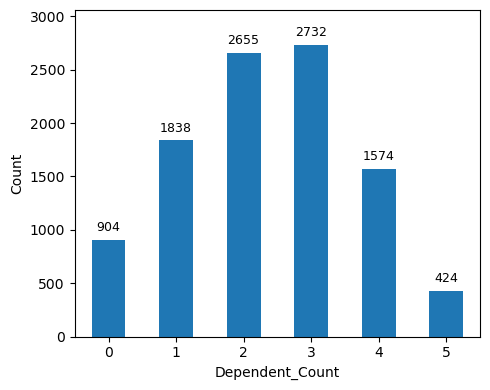

Text(0, 0.5, 'Count')

(0.0, 2581.6000000000004)

Text(0, 956.1, '910')

Text(1, 1289.1, '1243')

Text(2, 2351.1, '2305')

Text(3, 1958.1, '1912')

Text(4, 1937.1, '1891')

Text(5, 1912.1, '1866')

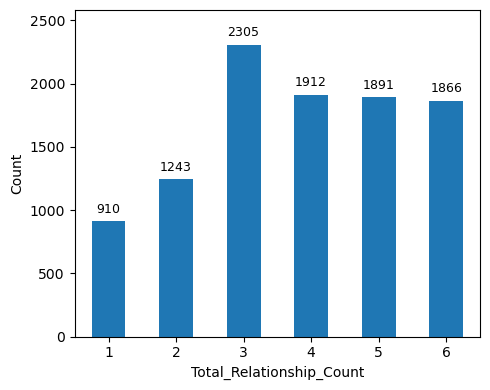

Text(0, 0.5, 'Count')

(0.0, 4307.52)

Text(0, 105.92, '29')

Text(1, 2309.92, '2233')

Text(2, 3358.92, '3282')

Text(3, 3922.92, '3846')

Text(4, 511.92, '435')

Text(5, 254.92000000000002, '178')

Text(6, 200.92000000000002, '124')

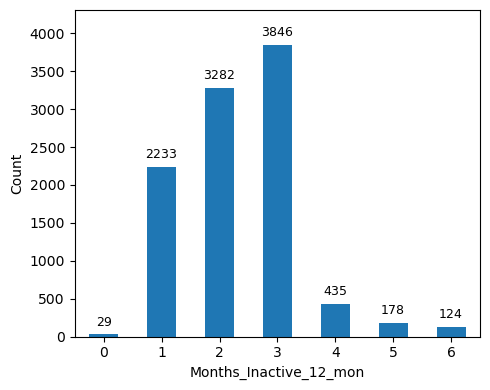

Text(0, 0.5, 'Count')

(0.0, 3785.6000000000004)

Text(0, 466.6, '399')

Text(1, 1566.6, '1499')

Text(2, 3294.6, '3227')

Text(3, 3447.6, '3380')

Text(4, 1459.6, '1392')

Text(5, 243.6, '176')

Text(6, 121.6, '54')

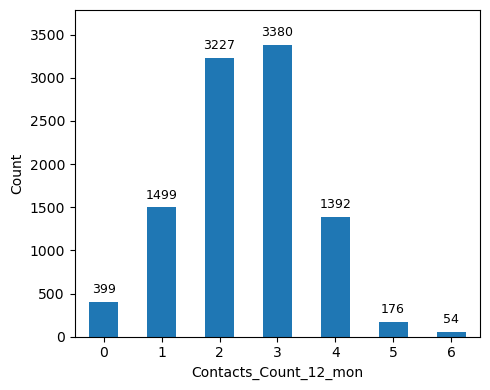

In [12]:
discrete_cols = [
    "Dependent_Count",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon"
]

for col in discrete_cols:
    # plt.figure(figsize=(5, 3))
    counts_discrete = raw_data_new[col].value_counts().sort_index()
    fig_discrete = counts_discrete.plot(
        kind = "bar",
        figsize = (5,4),
        rot = 0
    )

    plt.ylabel("Count")

    y_offset = counts_discrete.max() * 0.02
    fig_discrete.set_ylim(0, counts_discrete.max() * 1.12)

    for i, v in enumerate(counts_discrete.values):
        fig_discrete.text(i, v + y_offset, f"{v}", ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Class Distribution of Attrition Flag')

Text(0.5, 0, 'Status')

Text(0, 0.5, 'Number of Customers')

Text(0, 8540, '8500')

Text(1, 1667, '1627')

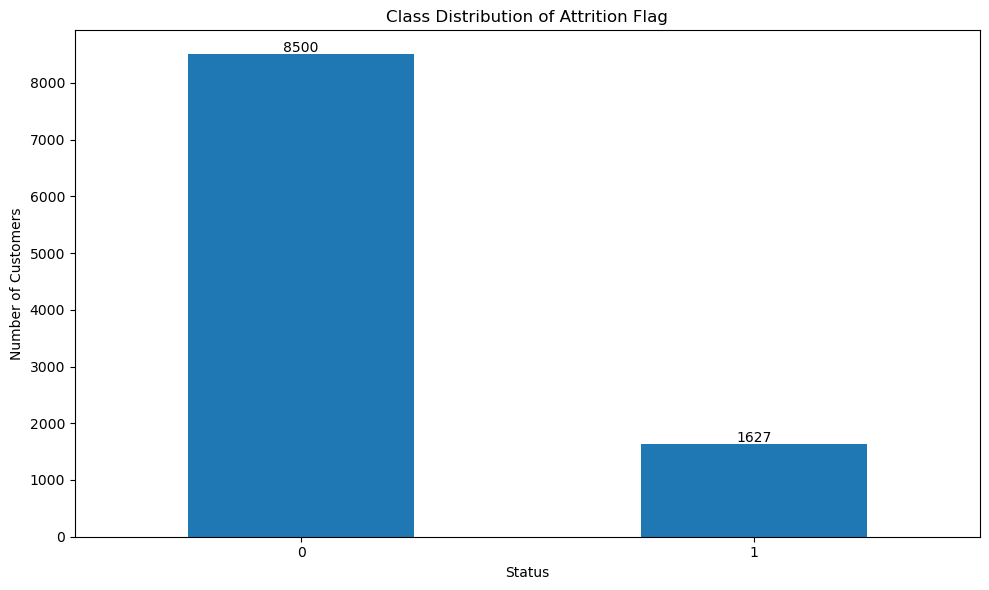

In [13]:
df = raw_data_new.copy()

# Encode the Target Variable
# Map 'Existing Customer' to 0 and 'Attrited Customer' to 1
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0, 
    "Attrited Customer": 1
})

attrition_flag_counts = df["Attrition_Flag"].value_counts()

fig1 = attrition_flag_counts.plot(
    kind = "bar", 
    figsize = (10,6), 
    rot = 0
)

plt.title("Class Distribution of Attrition Flag")
plt.xlabel("Status")
plt.ylabel("Number of Customers")

for i, v in enumerate(attrition_flag_counts):
    fig1.text(i, v + 40, str(v), ha='center')

plt.tight_layout()
plt.show()

## Create a Test Set

In [14]:
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=SEED,
    stratify=y, 
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

print("\nClass ratio - full:")
print(y.value_counts(normalize=True))
print("\nClass ratio - train:")
print(y_train.value_counts(normalize=True))
print("\nClass ratio - test:")
print(y_test.value_counts(normalize=True))

X_train: (8101, 19) y_train: (8101,)
X_test: (2026, 19) y_test: (2026,)

Class ratio - full:
Attrition_Flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64

Class ratio - train:
Attrition_Flag
0    0.839279
1    0.160721
Name: proportion, dtype: float64

Class ratio - test:
Attrition_Flag
0    0.839585
1    0.160415
Name: proportion, dtype: float64


# Section 2: Explore the Data to Gain Insights

In [15]:
eda_df = X_train.copy()
eda_df["Attrition_Flag"] = y_train

In [16]:
def analyze_continuous_feature(df, feature, target="Attrition_Flag"):
    """
    Analyze a continuous feature against a binary target.
    Print summary statistics, compare group means, compute mean difference, and visualize distribution.
    """
    
    # Display overall summary statistics
    print(f"\n====== Summary Statistics for {feature} ======")
    print(df[feature].describe())
    
    # Compute the mean and the difference between churned and retained customers
    print(f"\n====== Mean Comparison by {target}: {feature} ======")
    group_means = df.groupby(target)[feature].mean()
    mean_diff = group_means[1] - group_means[0]
    print(group_means)
    print(f"Mean Difference: {mean_diff:.4f}")
    
    # Visualize distribution using Kernel Density Estimation (KDE)
    plt.figure(figsize=(10,6))
    
    sns.kdeplot(
        data=df,
        x=feature,
        hue=target,
        common_norm=False
    )
    
    plt.title(f"Distribution of {feature} by Churn Status")
    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

In [17]:
def analyze_categorical_feature(df, col):
    """
    Calculate and rank the churn rate for a specific categorical feature and generate the bar chart.
    """
    table = pd.crosstab(
        df[col],
        df["Attrition_Flag"],
        normalize="index"
    )

    sorted_rate = table.sort_values(by=1, ascending=False)
    display(sorted_rate)

    plot_data = sorted_rate[1]

    plt.figure(figsize=(10,6))
    bar_chart = plot_data.plot(
        kind="bar", 
        rot=0)

    for i, v in enumerate(plot_data):
        bar_chart.text(
            i, 
            v + 0.002, 
            f'{v:.4f}', 
            ha='center',
            fontsize=10
        )

    plt.title(f"Churn Rate by {col}", fontsize=14)
    plt.ylabel("Churn Rate", fontsize=12)
    plt.xlabel(col, fontsize=12)
    
    plt.tight_layout()
    plt.show()

## Visualise Demographic Profile Data


====== Summary Statistics for Customer_Age ======
count    8101.000000
mean       46.390199
std         7.985385
min        26.000000
25%        41.000000
50%        46.000000
75%        52.000000
max        73.000000
Name: Customer_Age, dtype: float64

====== Mean Comparison by Attrition_Flag: Customer_Age ======
Attrition_Flag
0    46.329901
1    46.705069
Name: Customer_Age, dtype: float64
Mean Difference: 0.3752


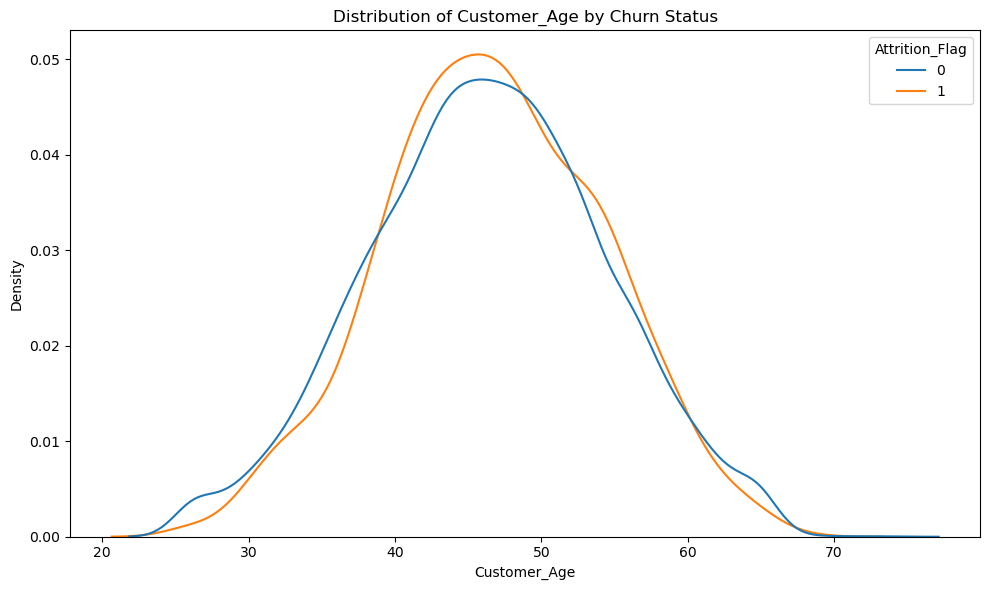

In [18]:
# ================== Explore Customer Age Distribution ==================
analyze_continuous_feature(eda_df, "Customer_Age")

Gender
F    4272
M    3829
Name: count, dtype: int64

Attrition_Flag,0,1
Gender,,
F,0.824672,0.175328
M,0.855576,0.144424


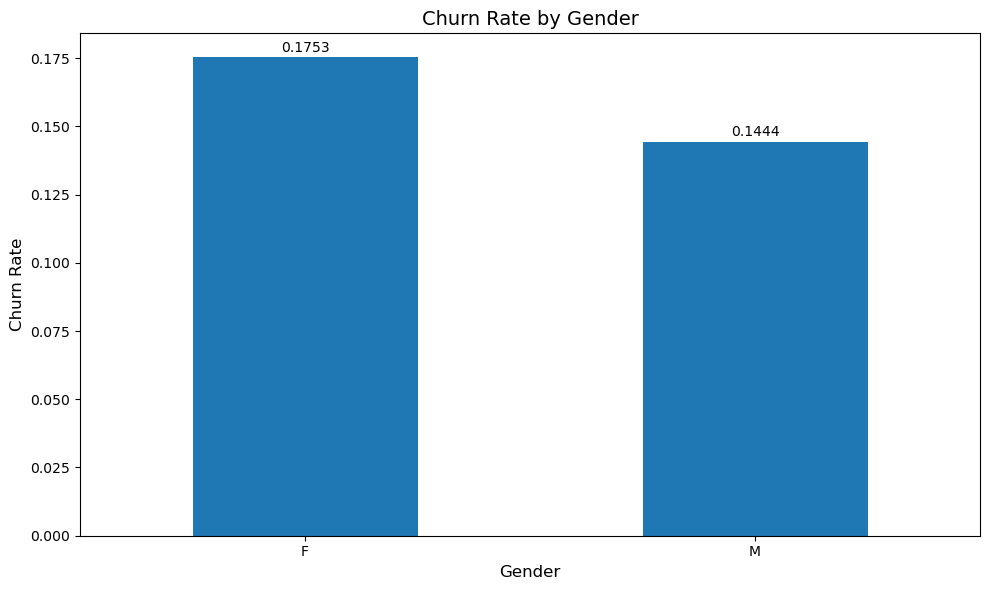

In [19]:
# ================== Explore Gender Distribution ==================
eda_df["Gender"].value_counts()
analyze_categorical_feature(eda_df, "Gender")

Education_Level
Graduate         2482
High School      1650
Unknown          1207
Uneducated       1183
College           796
Post-Graduate     427
Doctorate         356
Name: count, dtype: int64

Attrition_Flag,0,1
Education_Level,,
Doctorate,0.794944,0.205056
Unknown,0.830157,0.169843
Post-Graduate,0.831382,0.168618
Uneducated,0.834320,0.165680
High School,0.844848,0.155152
Graduate,0.846092,0.153908
College,0.851759,0.148241


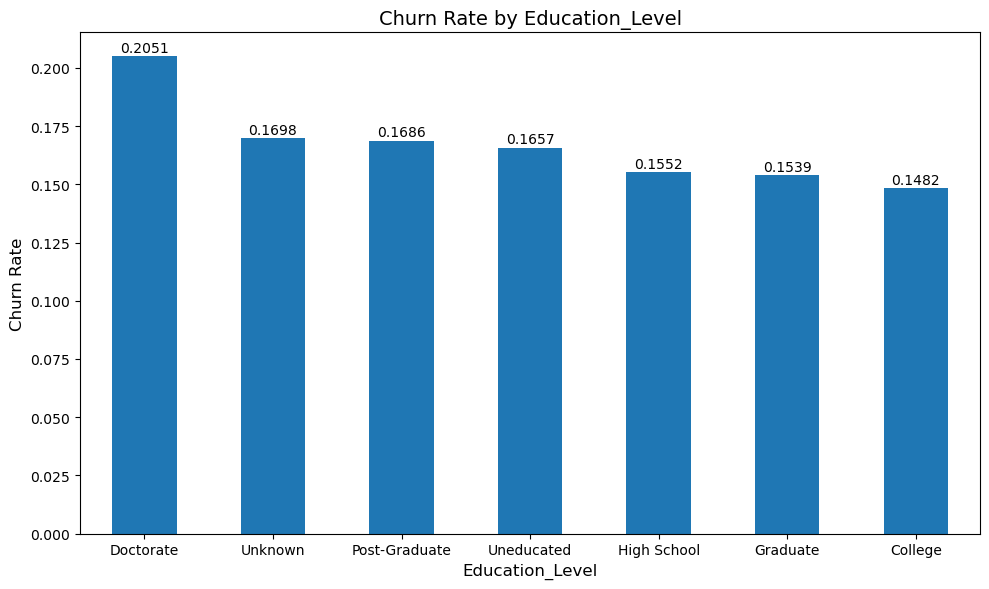

In [20]:
# ================== Explore Education Level Distribution ==================
eda_df["Education_Level"].value_counts()
analyze_categorical_feature(eda_df, "Education_Level")

Marital_Status
Married     3755
Single      3142
Unknown      605
Divorced     599
Name: count, dtype: int64

Attrition_Flag,0,1
Marital_Status,,
Unknown,0.821488,0.178512
Single,0.830999,0.169001
Married,0.846605,0.153395
Divorced,0.854758,0.145242


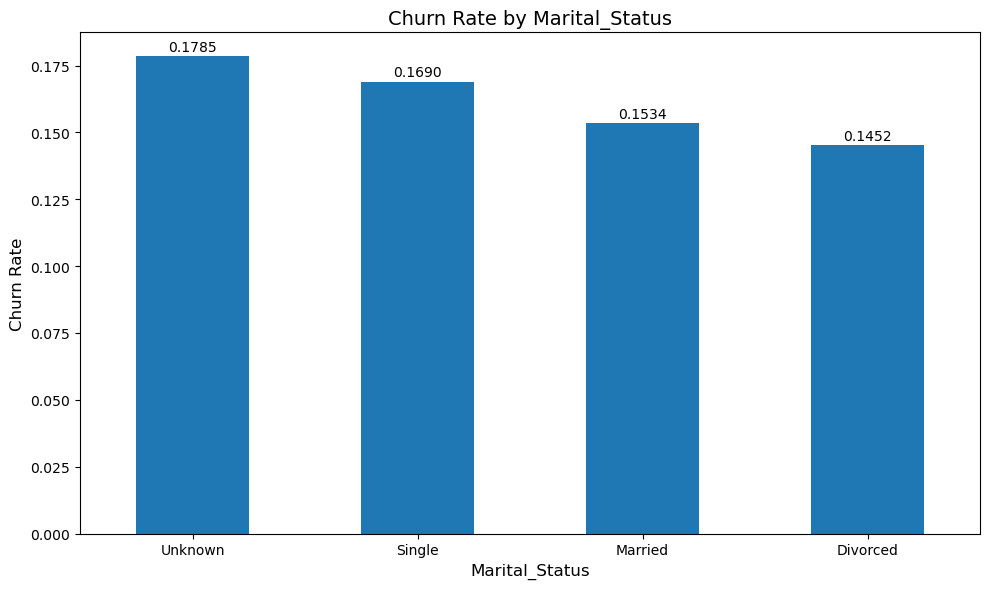

In [21]:
# ================== Explore Marital Status Distribution ==================
eda_df["Marital_Status"].value_counts()
analyze_categorical_feature(eda_df, "Marital_Status")

Income_Category
Less than $40K    2832
$40K - $60K       1450
$80K - $120K      1209
$60K - $80K       1136
Unknown            886
$120K +            588
Name: count, dtype: int64

Attrition_Flag,0,1
Income_Category,,
$120K +,0.821429,0.178571
Unknown,0.827314,0.172686
Less than $40K,0.827684,0.172316
$40K - $60K,0.848276,0.151724
$80K - $120K,0.851944,0.148056
$60K - $80K,0.861796,0.138204


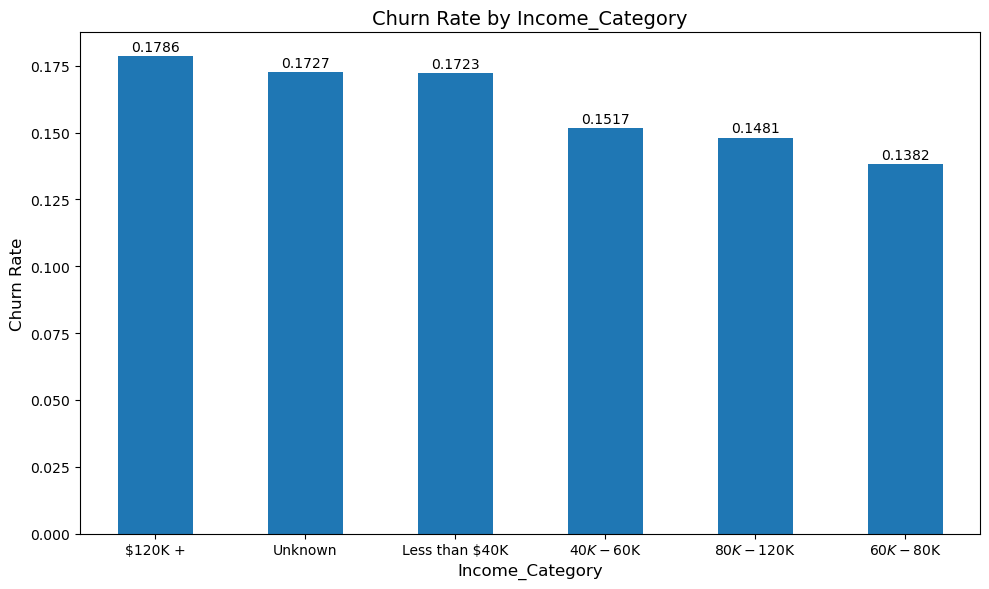

In [22]:
# ================== Explore Income Category Distribution ==================
eda_df["Income_Category"].value_counts()
analyze_categorical_feature(eda_df, "Income_Category")

## Visualise Customer Relationship Data

Card_Category
Blue        7559
Silver       431
Gold          94
Platinum      17
Name: count, dtype: int64

Attrition_Flag,0,1
Card_Category,,
Platinum,0.764706,0.235294
Gold,0.808511,0.191489
Blue,0.838868,0.161132
Silver,0.856148,0.143852


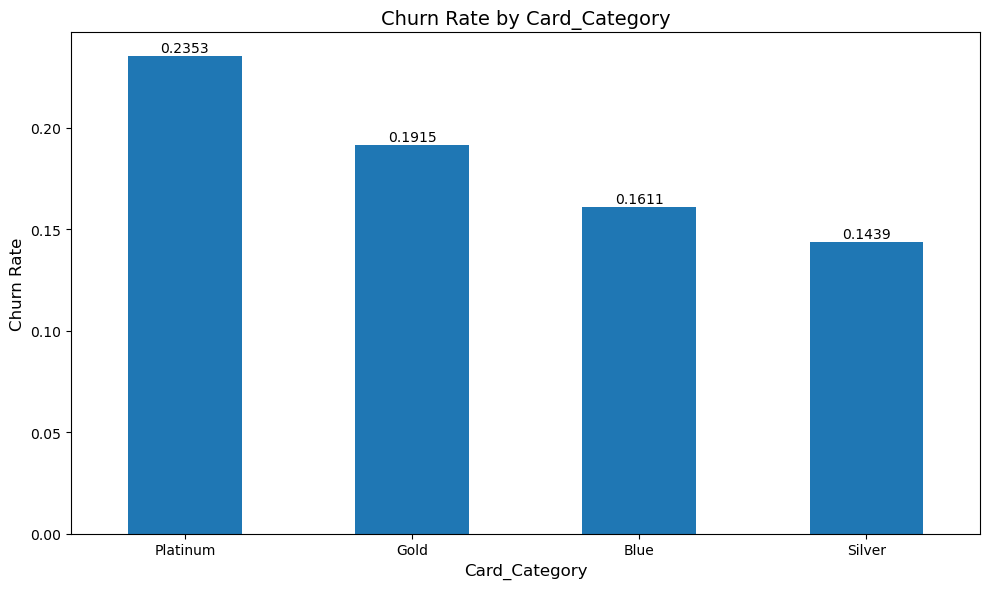

In [23]:
# ================== Explore Card Category Distribution ==================
eda_df["Card_Category"].value_counts()
analyze_categorical_feature(eda_df, "Card_Category")


====== Summary Statistics for Months_on_Book ======
count    8101.000000
mean       36.005555
std         7.934351
min        13.000000
25%        32.000000
50%        36.000000
75%        40.000000
max        56.000000
Name: Months_on_Book, dtype: float64

====== Mean Comparison by Attrition_Flag: Months_on_Book ======
Attrition_Flag
0    35.977350
1    36.152842
Name: Months_on_Book, dtype: float64
Mean Difference: 0.1755


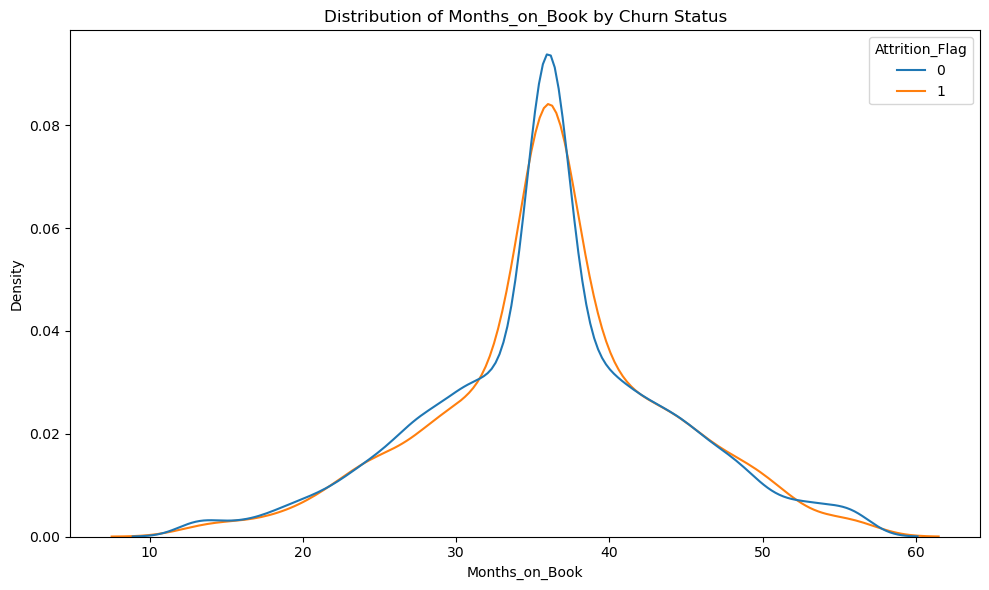

In [24]:
# ================== Explore the Length of the Customer Relationship with the Bank Distribution ==================
analyze_continuous_feature(eda_df, "Months_on_Book")

Total_Relationship_Count
1     743
2     961
3    1884
4    1498
5    1534
6    1481
Name: count, dtype: int64

Attrition_Flag,0,1
Total_Relationship_Count,,
2,0.713840,0.286160
1,0.732167,0.267833
3,0.831741,0.168259
4,0.881842,0.118158
5,0.883963,0.116037
6,0.894666,0.105334


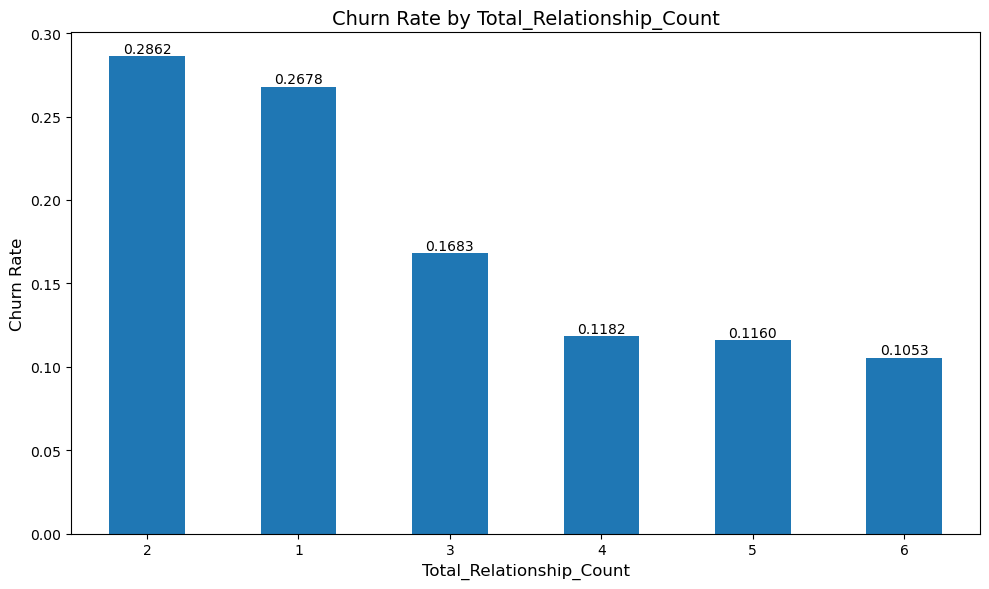

In [25]:
# ================== Explore Total Number of Financial Products Held by the Customer Distribution ==================
eda_df["Total_Relationship_Count"].value_counts().sort_index()
analyze_categorical_feature(eda_df, "Total_Relationship_Count")

## Visualize Behaviour Activity Data

Months_Inactive_12_mon
0      21
1    1771
2    2636
3    3073
4     356
5     143
6     101
Name: count, dtype: int64

Attrition_Flag,0,1
Months_Inactive_12_mon,,
0,0.476190,0.523810
4,0.688202,0.311798
3,0.780996,0.219004
5,0.832168,0.167832
2,0.848634,0.151366
6,0.871287,0.128713
1,0.959910,0.040090


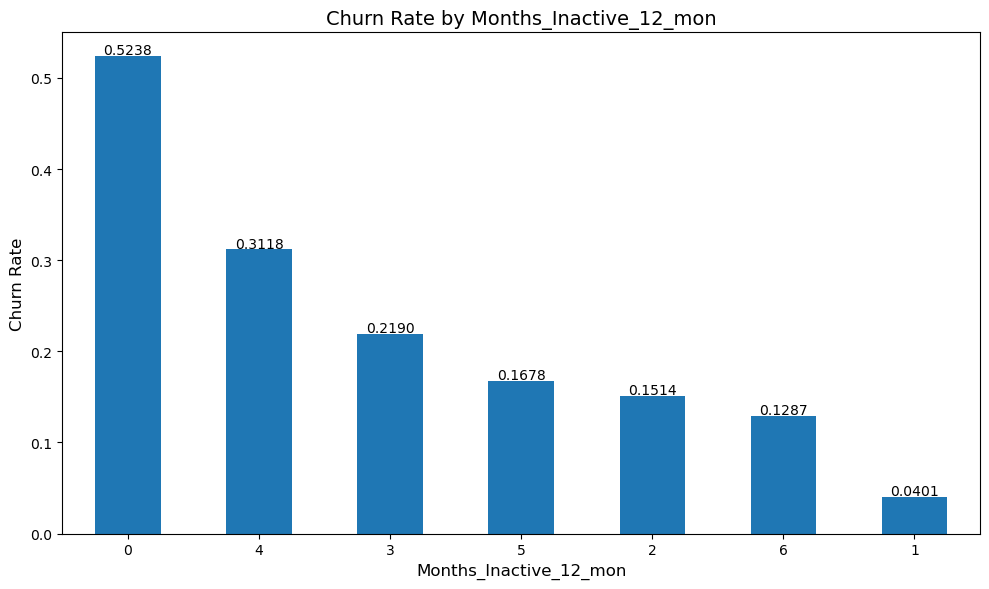

In [26]:
# ================== Explore Account Inactivity Distribution ==================
eda_df["Months_Inactive_12_mon"].value_counts().sort_index()
analyze_categorical_feature(eda_df, "Months_Inactive_12_mon")

Contacts_Count_12_mon
0     328
1    1195
2    2563
3    2712
4    1114
5     147
6      42
Name: count, dtype: int64

Attrition_Flag,0,1
Contacts_Count_12_mon,,
6,0.000000,1.000000
5,0.673469,0.326531
4,0.771095,0.228905
3,0.798673,0.201327
2,0.874756,0.125244
1,0.928870,0.071130
0,0.984756,0.015244


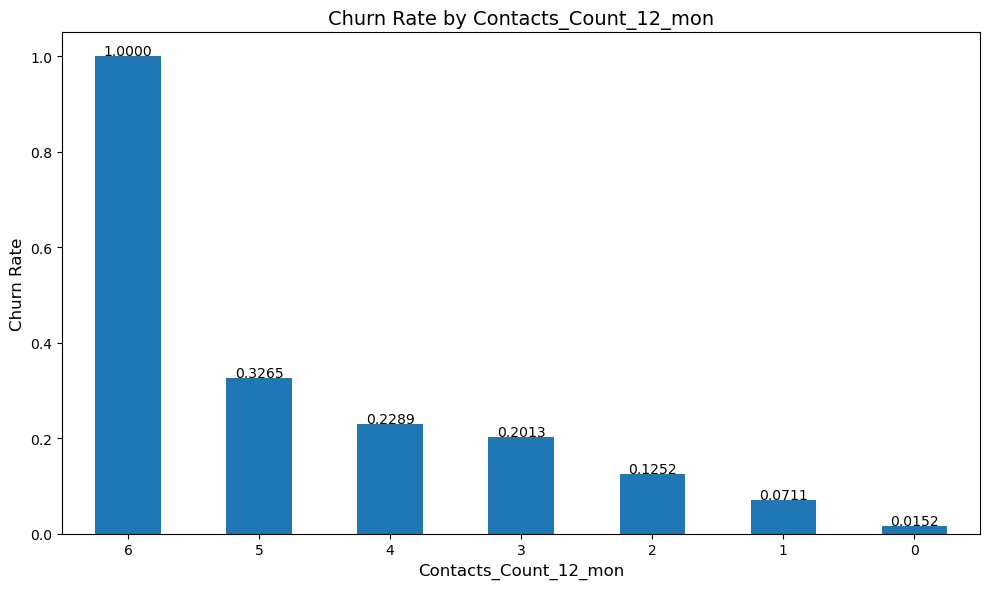

In [27]:
# ================== Explore Contact Frequency Distribution ==================
eda_df["Contacts_Count_12_mon"].value_counts().sort_index()
analyze_categorical_feature(eda_df, "Contacts_Count_12_mon")


====== Summary Statistics for Total_Trans_Amt ======
count     8101.000000
mean      4388.065054
std       3397.305917
min        530.000000
25%       2139.000000
50%       3894.000000
75%       4741.000000
max      17995.000000
Name: Total_Trans_Amt, dtype: float64

====== Mean Comparison by Attrition_Flag: Total_Trans_Amt ======
Attrition_Flag
0    4645.956317
1    3041.365591
Name: Total_Trans_Amt, dtype: float64
Mean Difference: -1604.5907


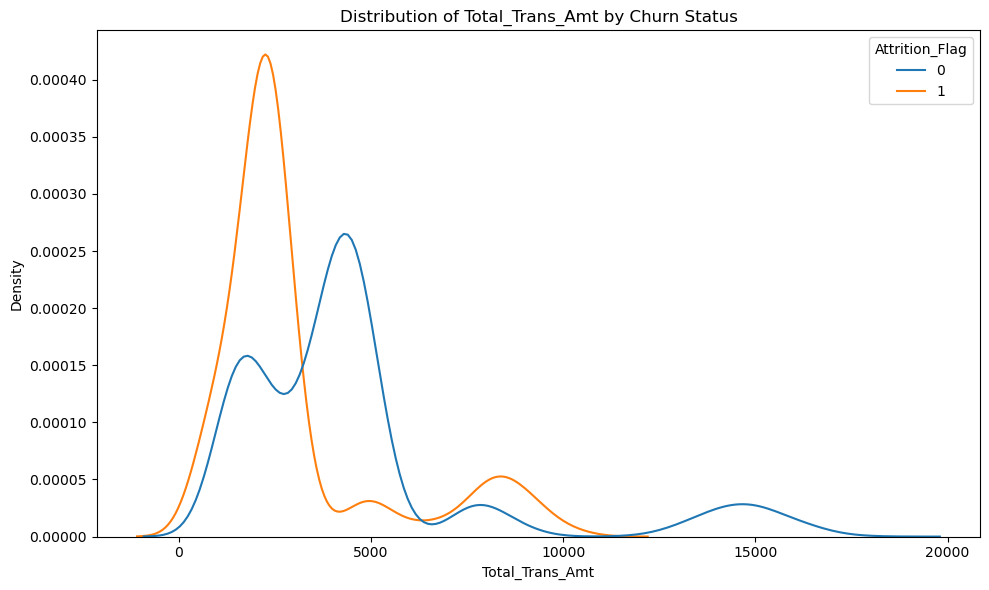

In [28]:
# ================== Explore Transaction Amount Distribution ==================
analyze_continuous_feature(eda_df, "Total_Trans_Amt")


====== Summary Statistics for Total_Trans_Ct ======
count    8101.000000
mean       64.701889
std        23.608831
min        10.000000
25%        45.000000
50%        67.000000
75%        81.000000
max       139.000000
Name: Total_Trans_Ct, dtype: float64

====== Mean Comparison by Attrition_Flag: Total_Trans_Ct ======
Attrition_Flag
0    68.550081
1    44.606759
Name: Total_Trans_Ct, dtype: float64
Mean Difference: -23.9433


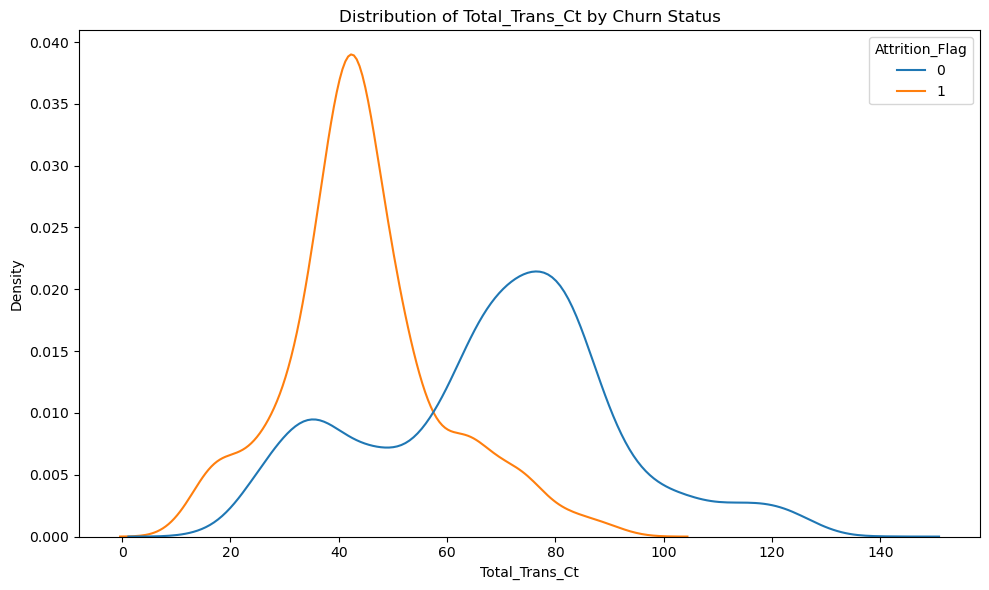

In [29]:
# ================== Explore Transaction Count Distribution ==================
analyze_continuous_feature(eda_df, "Total_Trans_Ct")


====== Summary Statistics for Total_Amt_Chng_Q4_Q1 ======
count    8101.000000
mean        0.759615
std         0.219369
min         0.000000
25%         0.630000
50%         0.735000
75%         0.859000
max         3.397000
Name: Total_Amt_Chng_Q4_Q1, dtype: float64

====== Mean Comparison by Attrition_Flag: Total_Amt_Chng_Q4_Q1 ======
Attrition_Flag
0    0.772013
1    0.694873
Name: Total_Amt_Chng_Q4_Q1, dtype: float64
Mean Difference: -0.0771


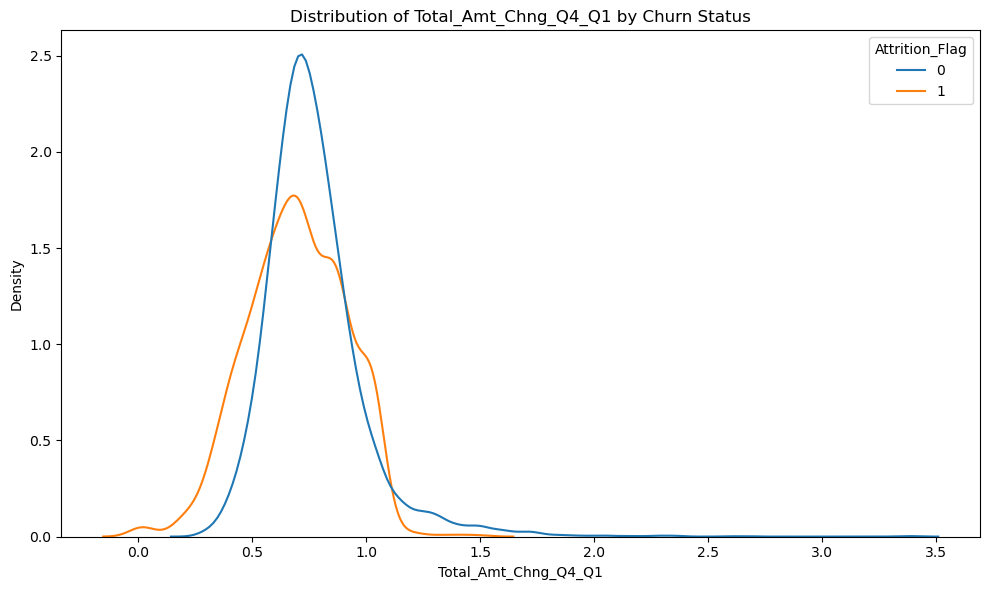

In [30]:
# ================== Explore the Change in Transaction Amount (Q4 over Q1) Distribution ==================
analyze_continuous_feature(eda_df, "Total_Amt_Chng_Q4_Q1")


====== Summary Statistics for Total_Ct_Chng_Q4_Q1 ======
count    8101.000000
mean        0.713369
std         0.242677
min         0.000000
25%         0.581000
50%         0.702000
75%         0.818000
max         3.714000
Name: Total_Ct_Chng_Q4_Q1, dtype: float64

====== Mean Comparison by Attrition_Flag: Total_Ct_Chng_Q4_Q1 ======
Attrition_Flag
0    0.743790
1    0.554513
Name: Total_Ct_Chng_Q4_Q1, dtype: float64
Mean Difference: -0.1893


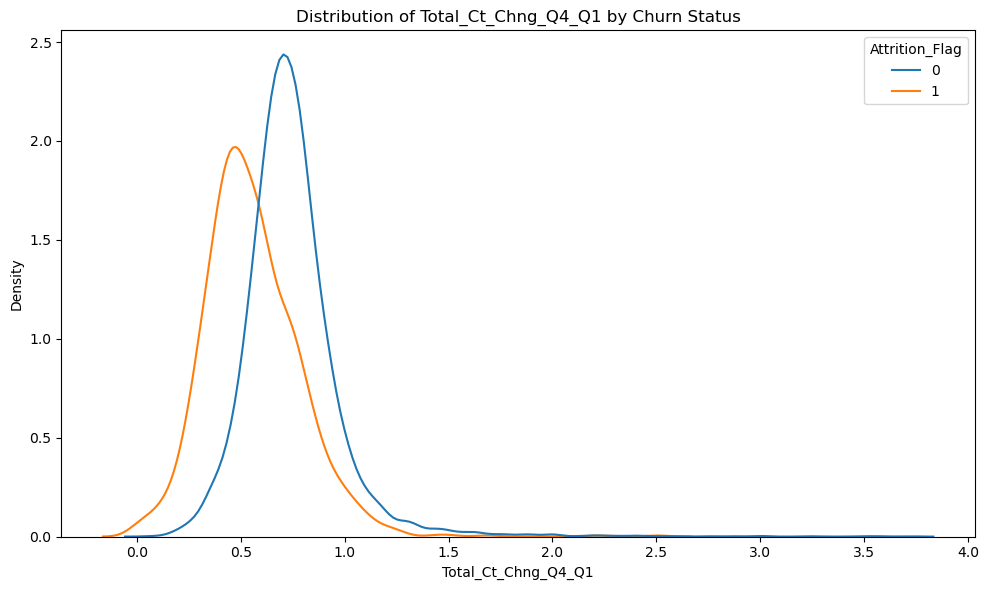

In [31]:
# ================== Explore the Change in Transaction Count (Q4 over Q1) Distribution ==================
analyze_continuous_feature(eda_df, "Total_Ct_Chng_Q4_Q1")

## Visualize Financial Attribute Data


====== Summary Statistics for Credit_Limit ======
count     8101.000000
mean      8580.069991
std       9032.362733
min       1438.300000
25%       2562.000000
50%       4532.000000
75%      10973.000000
max      34516.000000
Name: Credit_Limit, dtype: float64

====== Mean Comparison by Attrition_Flag: Credit_Limit ======
Attrition_Flag
0    8674.832181
1    8085.225038
Name: Credit_Limit, dtype: float64
Mean Difference: -589.6071


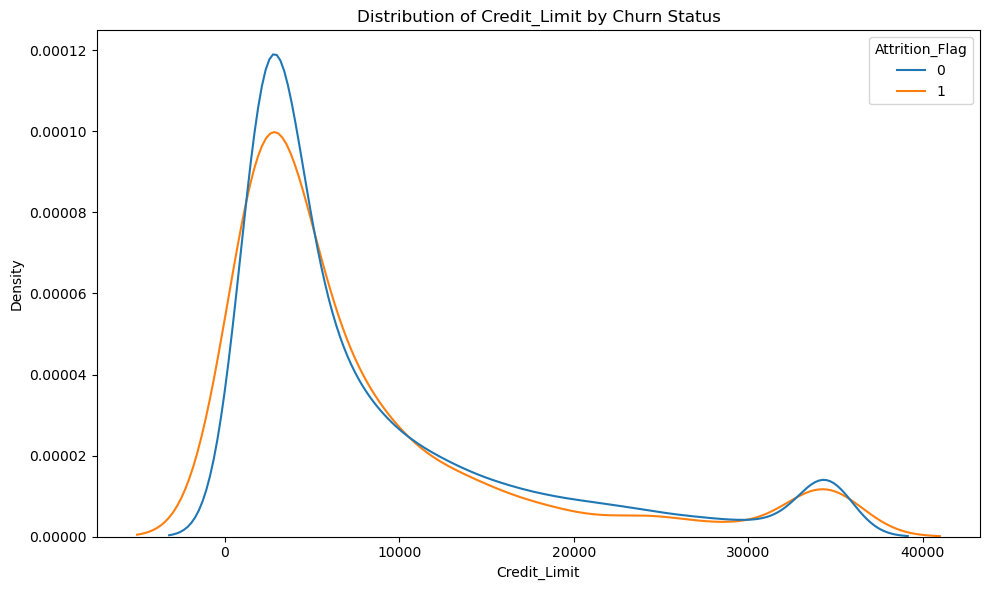

In [32]:
# ================== Explore Credit Limit Distribution ==================
analyze_continuous_feature(eda_df, "Credit_Limit")


====== Summary Statistics for Total_Revolving_Bal ======
count    8101.000000
mean     1167.672139
std       814.755132
min         0.000000
25%       411.000000
50%      1289.000000
75%      1786.000000
max      2517.000000
Name: Total_Revolving_Bal, dtype: float64

====== Mean Comparison by Attrition_Flag: Total_Revolving_Bal ======
Attrition_Flag
0    1263.072217
1     669.496160
Name: Total_Revolving_Bal, dtype: float64
Mean Difference: -593.5761


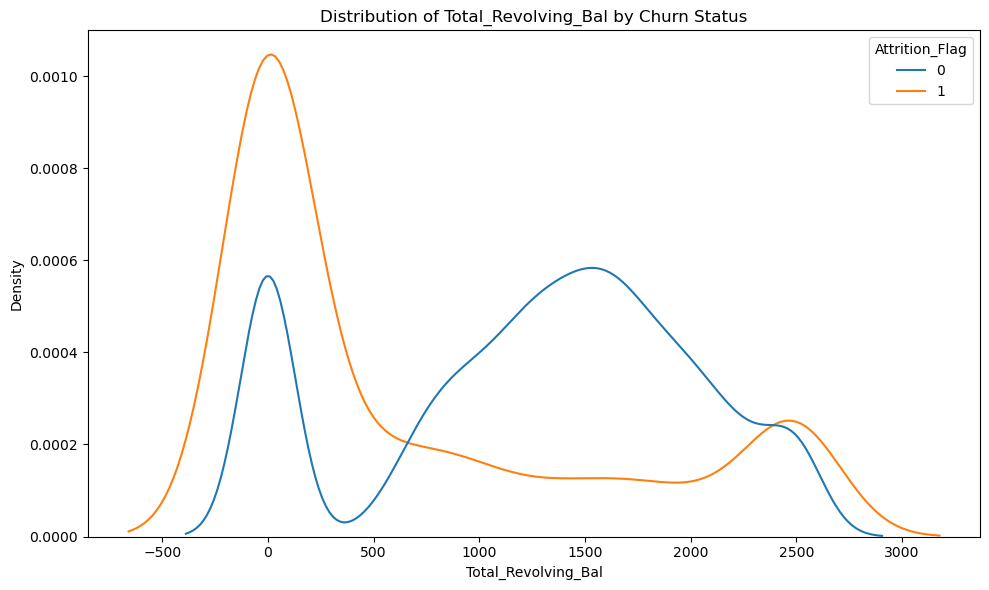

In [33]:
# ================== Explore Revolving Balance Distribution ==================
analyze_continuous_feature(eda_df, "Total_Revolving_Bal")


====== Summary Statistics for Avg_Open_To_Buy ======
count     8101.000000
mean      7412.397852
std       9032.331209
min         10.000000
25%       1329.000000
50%       3454.000000
75%       9750.000000
max      34516.000000
Name: Avg_Open_To_Buy, dtype: float64

====== Mean Comparison by Attrition_Flag: Avg_Open_To_Buy ======
Attrition_Flag
0    7411.759965
1    7415.728879
Name: Avg_Open_To_Buy, dtype: float64
Mean Difference: 3.9689


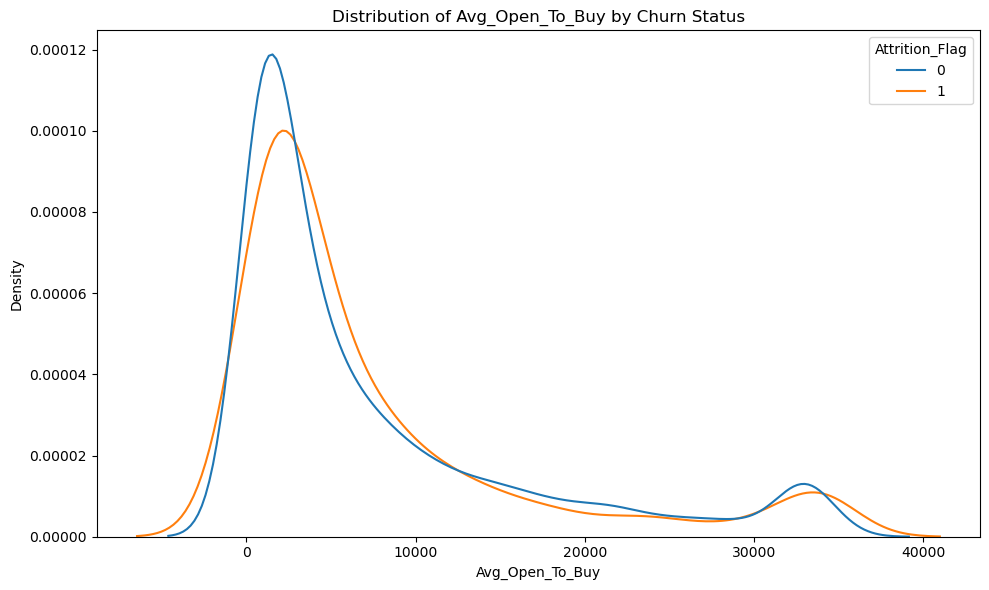

In [34]:
# ================== Explore Available Credit Line Distribution ==================
analyze_continuous_feature(eda_df, "Avg_Open_To_Buy")


====== Summary Statistics for Avg_Utilization_Ratio ======
count    8101.000000
mean        0.275668
std         0.275665
min         0.000000
25%         0.025000
50%         0.177000
75%         0.504000
max         0.995000
Name: Avg_Utilization_Ratio, dtype: float64

====== Mean Comparison by Attrition_Flag: Avg_Utilization_Ratio ======
Attrition_Flag
0    0.298408
1    0.156920
Name: Avg_Utilization_Ratio, dtype: float64
Mean Difference: -0.1415


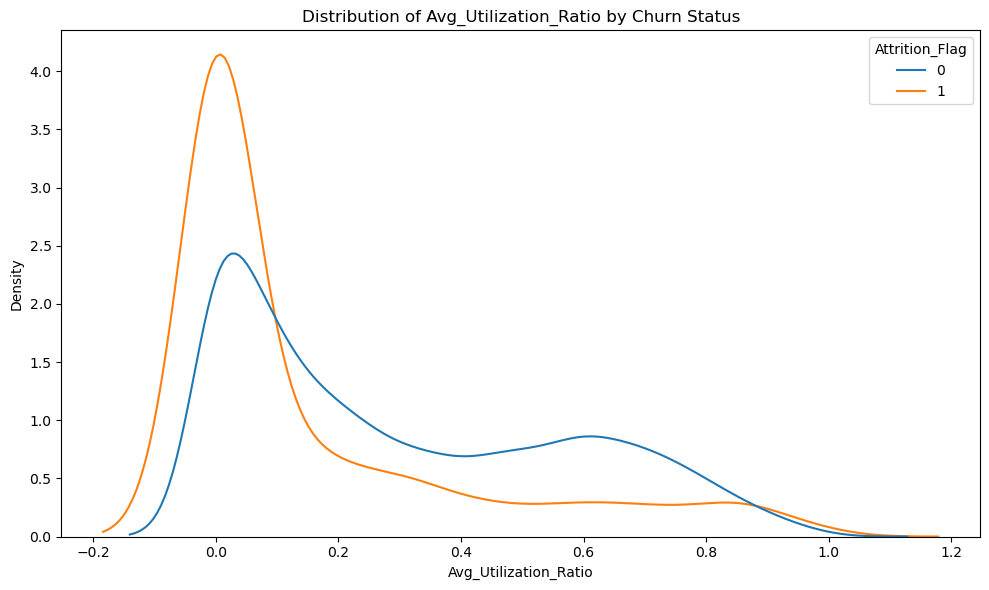

In [35]:
# ================== Explore Card Utilization Distribution ==================
analyze_continuous_feature(eda_df, "Avg_Utilization_Ratio")

# Section 3: Prepare the Data for Machine Learning Algorithm

In [36]:
# Add project root to import path for src package
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import prepare_dataset

dataset = prepare_dataset()
X_train = dataset.X_train
X_test = dataset.X_test
y_train = dataset.y_train
y_test = dataset.y_test

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("Train class ratio:", y_train.value_counts(normalize=True).to_dict())
print("Test class ratio:", y_test.value_counts(normalize=True).to_dict())


X_train: (8101, 19) y_train: (8101,)
X_test: (2026, 19) y_test: (2026,)
Train class ratio: {0: 0.8392791013455129, 1: 0.1607208986544871}
Test class ratio: {0: 0.8395853899308984, 1: 0.16041461006910168}


In [ ]:
# Optional quick sanity check of modular preprocessing builder
from src.preprocess import build_pipeline
from sklearn.linear_model import LogisticRegression

sanity_pipeline = build_pipeline(LogisticRegression(max_iter=500, random_state=SEED))
sanity_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Customer_Age',
                                                   'Dependent_Count',
                                                   'Months_on_Book',
                                                   'Total_Relationship_Count',
                                                   'Months_Inactive_12_mon',
                                                   'Contacts_Count_12_mon',
                                                   'Credit_Limit',
                                                   'Total_Revolving_Bal',
                                                   'Avg_Open_To_Buy',
                                                   'Total_A...
                                                   'Total_Trans_Ct',
                                                   'Total_Ct_Chng_Q4_Q1',
                                                   'Avg_Utilization_Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Education_Level',
                                                   'Marital_Status',
                                                   'Income_Category',
                                                   'Card_Category'])])),
                ('model', LogisticRegression(max_iter=500, random_state=42))])

# Section 4: Select and Train the Model

In [38]:
from src.train import run_train_stage

train_out = run_train_stage()
print(train_out)

comparison_df = pd.read_csv(TABLES_DIR / "step4_model_comparison.csv")
comparison_df

{'shortlist_models': ['hist_gradient_boosting', 'random_forest'], 'best_model_name': 'hist_gradient_boosting', 'table_path': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individual Assignment/artifacts/tables/step4_model_comparison.csv'}


,model,cv_roc_auc_mean,cv_roc_auc_std,cv_pr_auc_mean,cv_pr_auc_std,cv_f1_mean,cv_f1_std,cv_recall_mean,cv_recall_std
0,hist_gradient_boosting,0.993384,0.001176,0.968740,0.007429,0.909881,0.008809,0.884035,0.013965
1,random_forest,0.986683,0.003029,0.935367,0.016986,0.843841,0.023795,0.798022,0.030176
2,logistic_regression,0.925294,0.007480,0.747540,0.018454,0.643401,0.016846,0.848718,0.020817
3,baseline_dummy,0.500000,0.000000,0.160721,0.000280,0.000000,0.000000,0.000000,0.000000


# Section 5: Fine-Tune and Evaluate the Model

In [39]:
from src.tune import run_tune_stage

tune_out = run_tune_stage()
print(tune_out)

{'best_model_name': 'hist_gradient_boosting', 'best_params': {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 31, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}, 'best_cv_roc_auc': 0.9934533202449304, 'best_threshold': 0.4}


In [40]:
from src.evaluate import run_evaluate_stage

eval_out = run_evaluate_stage()
print(eval_out)

{'best_model_name': 'hist_gradient_boosting', 'best_params': {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 31, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.0}, 'best_threshold': 0.4, 'test_metrics_default_0_5': {'accuracy': 0.9708785784797631, 'precision': 0.9375, 'recall': 0.8769230769230769, 'f1': 0.9062003179650239, 'roc_auc': 0.9918961696739474, 'pr_auc': 0.9639741588753681}, 'test_metrics_tuned_threshold': {'accuracy': 0.9684106614017769, 'precision': 0.9169329073482428, 'recall': 0.8830769230769231, 'f1': 0.8996865203761756, 'roc_auc': 0.9918961696739474, 'pr_auc': 0.9639741588753681}, 'classification_report_path': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individual Assignment/artifacts/reports/step5_classification_report_tuned.txt', 'plots': {'calibration': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individual Assignment/artifacts/plots/step5_calibration_curve_test.png', 'confusion_matrix_tuned': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individ

In [41]:
# Load generated reports for easy notebook display
step5_tuning = json.loads((REPORTS_DIR / "step5_tuning_report.json").read_text(encoding="utf-8"))
step5_eval = json.loads((REPORTS_DIR / "step5_evaluation_report.json").read_text(encoding="utf-8"))

print("Best model:", step5_tuning["best_model_name"])
print("Best threshold:", step5_tuning["best_threshold"])
print("Test metrics @0.5:", step5_eval["test_metrics_default_0_5"])
print("Test metrics @best_t:", step5_eval["test_metrics_tuned_threshold"])

pd.DataFrame([
    {"variant": "default_0.5", **step5_eval["test_metrics_default_0_5"]},
    {"variant": "tuned_threshold", **step5_eval["test_metrics_tuned_threshold"]},
])

Best model: hist_gradient_boosting
Best threshold: 0.4
Test metrics @0.5: {'accuracy': 0.9708785784797631, 'precision': 0.9375, 'recall': 0.8769230769230769, 'f1': 0.9062003179650239, 'roc_auc': 0.9918961696739474, 'pr_auc': 0.9639741588753681}
Test metrics @best_t: {'accuracy': 0.9684106614017769, 'precision': 0.9169329073482428, 'recall': 0.8830769230769231, 'f1': 0.8996865203761756, 'roc_auc': 0.9918961696739474, 'pr_auc': 0.9639741588753681}


,variant,accuracy,precision,recall,f1,roc_auc,pr_auc
0,default_0.5,0.970879,0.937500,0.876923,0.906200,0.991896,0.963974
1,tuned_threshold,0.968411,0.916933,0.883077,0.899687,0.991896,0.963974


# Section 6: Present the Final Solution

In [ ]:
summary_payload = {
    "final_model": step5_tuning["best_model_name"],
    "best_params": step5_tuning["best_params"],
    "decision_threshold": step5_tuning["best_threshold"],
    "test_metrics_default_0_5": step5_eval["test_metrics_default_0_5"],
    "test_metrics_tuned_threshold": step5_eval["test_metrics_tuned_threshold"],
    "artifacts": {
        "model_pickle": str(MODELS_DIR / "step5_best_model.pkl"),
        "model_comparison_table": str(TABLES_DIR / "step4_model_comparison.csv"),
        "tuning_report": str(REPORTS_DIR / "step5_tuning_report.json"),
        "evaluation_report": str(REPORTS_DIR / "step5_evaluation_report.json"),
    },
}

(REPORTS_DIR / "step6_final_summary_industrial.json").write_text(
    json.dumps(summary_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

model_card = f"""
# Model Card (Industrialized Notebook Version)

## What it is for
- Predict customer churn risk to support retention prioritization.

## What it is NOT for
- Not for fully automated adverse decisions without human review.

## Data provenance and constraints
- Data source: {RAW_DATA_PATH}
- Split strategy: stratified train/test from `src.data.prepare_dataset()`
- Constraint: static snapshot data, potential drift over time.

## Evaluation summary
- Final model: {summary_payload['final_model']}
- Threshold: {summary_payload['decision_threshold']}
- Test metrics @ tuned threshold: {summary_payload['test_metrics_tuned_threshold']}

## Caveats
- Threshold should be revisited if business cost assumptions change.
- Monitor calibration and subgroup performance after deployment.
""".strip()

(REPORTS_DIR / "model_card_industrial.md").write_text(model_card, encoding="utf-8")

summary_payload


1276

944

{'final_model': 'hist_gradient_boosting',
 'best_params': {'model__min_samples_leaf': 10,
  'model__max_leaf_nodes': 31,
  'model__learning_rate': 0.1,
  'model__l2_regularization': 0.0},
 'decision_threshold': 0.4,
 'test_metrics_default_0_5': {'accuracy': 0.9708785784797631,
  'precision': 0.9375,
  'recall': 0.8769230769230769,
  'f1': 0.9062003179650239,
  'roc_auc': 0.9918961696739474,
  'pr_auc': 0.9639741588753681},
 'test_metrics_tuned_threshold': {'accuracy': 0.9684106614017769,
  'precision': 0.9169329073482428,
  'recall': 0.8830769230769231,
  'f1': 0.8996865203761756,
  'roc_auc': 0.9918961696739474,
  'pr_auc': 0.9639741588753681},
 'artifacts': {'model_pickle': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individual Assignment/artifacts/models/step5_best_model.pkl',
  'model_comparison_table': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Individual Assignment/artifacts/tables/step4_model_comparison.csv',
  'tuning_report': '/Users/lingzitong/Desktop/我爱学习/UCL/MSIN0097/Ind